In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import glob
import pandas as pd 
import scipy as sp 
import scipy.stats as sps
import astropy
from astropy.io import fits
from scipy.stats import poisson
import statsmodels as sm
from scipy.special import gammaln
from matplotlib.ticker import MultipleLocator, AutoMinorLocator


# colors 
# special plot params
plt.style.use('dark_background')
plt.rcParams['axes.facecolor'] = 'midnightblue'
plt.rcParams['figure.facecolor'] = "#060552"
plt.rcParams['axes.grid'] = 'True'
plt.rcParams['grid.color'] = 'steelblue'
plt.rcParams['grid.linewidth'] = 0.6
plt.rcParams['grid.alpha'] = 0.8
plt.rcParams['axes.edgecolor'] = 'white'
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['legend.facecolor'] = "#060552"



In [42]:
# name files here, wherever your normed median .txt files are, or you can just navigate to the ones that are in the main data folder
# BUT: this should actually work if you just change everything up to /.../lapalma_analysis
# this should work if you just change the file path to where you cloned the folder to and (like before )


median_1 = '/Users/leayamashiro/AnA_MSc/Observations/git/lapalma_analysis/data/our_data051026/full_median/normalised/median_combined_051026_norm.txt'
median_2 = '/Users/leayamashiro/AnA_MSc/Observations/git/lapalma_analysis/data/our_data051026/full_median/normalised/median_combined_2_051026_norm.txt'

In [8]:
median1_np = np.loadtxt(median_1)
median1_np

array([[6.30002454e+03, 1.01077010e+00],
       [6.30005730e+03, 9.91203243e-01],
       [6.30009007e+03, 9.99131424e-01],
       ...,
       [6.81990561e+03, 1.02688890e+00],
       [6.81994108e+03, 1.02870593e+00],
       [6.81997655e+03, 1.01889869e+00]], shape=(15250, 2))

Make sure it's a spectrum: 

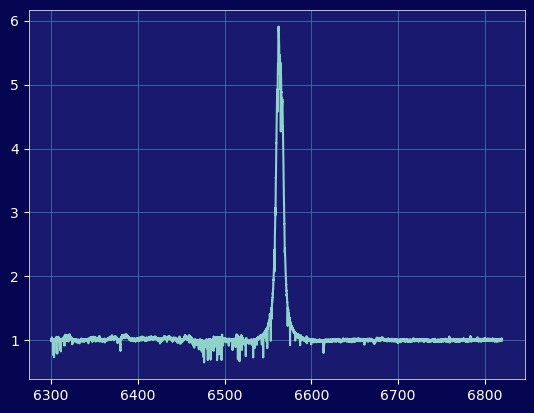

In [9]:
plt.plot(median1_np[:,0], median1_np[:,1])

figure out good cropping: 

In [10]:
%matplotlib qt

In [12]:
plt.plot(median1_np[:,0], median1_np[:,1], lw=0.5)

plt.xlim(6520, 6610)

# do this to see about where the H-alpha line rises and then falls back to 
# zero (this is to find where we want to do the integration for equivalent width)
# don't think we can just do it as a zero-crossing thing because there are some deeper dips 
# but they don't really represent where things go to zero 

(6520.0, 6610.0)

In [20]:
plt.ioff

<function matplotlib.pyplot.ioff() -> 'AbstractContextManager'>

Now try to calculate EW: 

In [21]:
# 6537.7 = left 
# 6594 = right 
# (writing here while doing interactive above)
import matplotlib.pyplot as plt # reloading to hopefully reset interactive...

h_alpha_left = 6537.7 # left bound
h_alpha_right = 6594 # right bound 

wl = median1_np[:,0] # wavelength array 
flux = median1_np[:,1] # flux array
 
line_mask = ( # create mask for the integration windows
    (wl >= h_alpha_left) &
    (wl <= h_alpha_right)
) 

line_wave = wl[line_mask] # cut wavelength array for integration
line_flux = flux[line_mask] # cut flux array for integration 

EW = np.trapezoid( # actually do the integral
    1.0 - line_flux,
    line_wave
)

print(np.abs(EW))


51.04400021970811


In [26]:
plt.ioff()

51.04400021970811


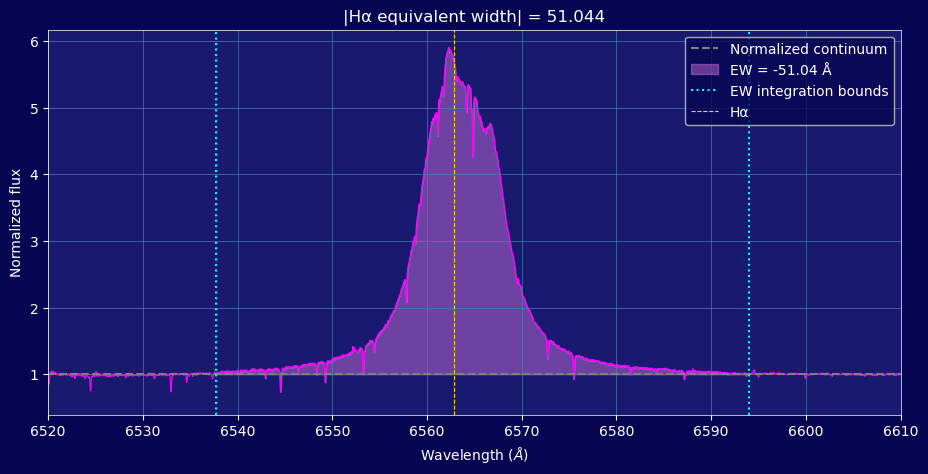

In [40]:
# To plot as well as calculate EW: 

import matplotlib.pyplot as plt # reloading to hopefully reset interactive...

h_alpha_left = 6537.7 # left bound
h_alpha_right = 6594 # right bound 

wl = median1_np[:,0] # wavelength array 
flux = median1_np[:,1] # flux array
 
line_mask = ( # create mask for the integration windows
    (wl >= h_alpha_left) &
    (wl <= h_alpha_right)
) 

line_wave = wl[line_mask] # cut wavelength array for integration
line_flux = flux[line_mask] # cut flux array for integration 

EW = np.trapezoid( # actually do the integral
    1.0 - line_flux,
    line_wave
)

print(np.abs(EW))

# plotting: 
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(wl, flux, color="magenta", lw=0.8)

ax.axhline(
    1.0,
    color="gray",
    linestyle="--",
    label="Normalized continuum"
)

ax.fill_between(
    line_wave,
    1.0,
    line_flux,
    color="violet",
    alpha=0.4,
    label=f"EW = {EW:.2f} Å"
)


ax.axvline(h_alpha_left, color="cyan", linestyle=":")
ax.axvline(h_alpha_right, color="cyan", linestyle=":", label = 'EW integration bounds')
ax.axvline(6562.8, ls="--", label="Hα", lw = 0.8, color = 'gold')

ax.set_xlim(6520, 6610)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Normalized flux")
ax.set_title(f"|Hα equivalent width| = {np.abs(EW):.3f}")
ax.legend()

fig

In [ ]:
# function to bring in normalized spectra and then calculate EW 

def calculate_EW(median_spec, )

### now trying with the second normalization version 

In [43]:
# %matplotlib qt
median2_np = np.loadtxt(median_2)
plt.plot(median2_np[:,0], median2_np[:,1], lw=0.5)

In [44]:
# 6535 = left 
# 6586 = right 

# set integration bounds of h-alpha (half)
h_alpha_left = 6535
h_alpha_right = 6586

wl = median2_np[:,0]
flux = median2_np[:,1]

line_mask = (
    (wl >= h_alpha_left) &
    (wl <= h_alpha_right)
)

line_wave = wl[line_mask]
line_flux = flux[line_mask]

EW = np.trapezoid(
    1.0 - line_flux,
    line_wave
)
print(np.abs(EW))

47.42502222773655


47.31136362137793


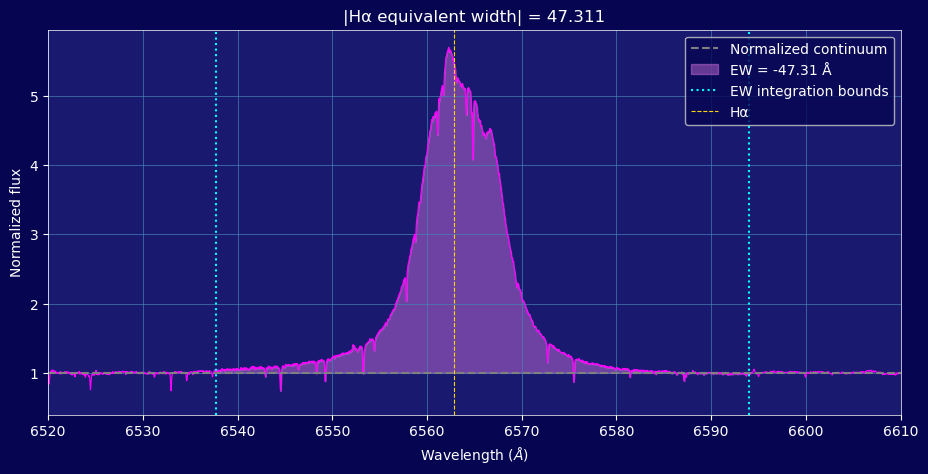

In [45]:
# To plot as well as calculate EW: 

import matplotlib.pyplot as plt # reloading to hopefully reset interactive...

h_alpha_left = 6537.7 # left bound
h_alpha_right = 6594 # right bound 

wl = median2_np[:,0] # wavelength array 
flux = median2_np[:,1] # flux array
 
line_mask = ( # create mask for the integration windows
    (wl >= h_alpha_left) &
    (wl <= h_alpha_right)
) 

line_wave = wl[line_mask] # cut wavelength array for integration
line_flux = flux[line_mask] # cut flux array for integration 

EW = np.trapezoid( # actually do the integral
    1.0 - line_flux,
    line_wave
)

print(np.abs(EW))

# plotting: 
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(wl, flux, color="magenta", lw=0.8)

ax.axhline(
    1.0,
    color="gray",
    linestyle="--",
    label="Normalized continuum"
)

ax.fill_between(
    line_wave,
    1.0,
    line_flux,
    color="violet",
    alpha=0.4,
    label=f"EW = {EW:.2f} Å"
)


ax.axvline(h_alpha_left, color="cyan", linestyle=":")
ax.axvline(h_alpha_right, color="cyan", linestyle=":", label = 'EW integration bounds')
ax.axvline(6562.8, ls="--", label="Hα", lw = 0.8, color = 'gold')

ax.set_xlim(6520, 6610)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Normalized flux")
ax.set_title(f"|Hα equivalent width| = {np.abs(EW):.3f}")
ax.legend()

fig

#### Okay so this is bad because me doing the normalization 2 separate times on the same spectra yielded a difference in EW of about 4 angstroms. No bueno!! I think the next thing is to not normalize by fitting a line but by fitting a polynomial of N degrees (like maybe 5 or 6 even). 